In [1]:
import pandas as pd
import numpy as np
import torch
import time
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

ModuleNotFoundError: No module named 'shap'

In [ ]:
# loading dataset
dataset = load_dataset("wassim249/ids-bot-iot", split="train")
df = dataset.to_pandas()

In [ ]:
df = df.sample(n=100000, random_state=42)
print("Dataset shape:", df.shape)

Dataset shape: (100000, 25)


In [ ]:
df.head()

,MI_dir_L0.1_weight,MI_dir_L0.1_mean,MI_dir_L0.1_variance,H_L0.1_weight,H_L0.1_mean,H_L0.1_variance,HH_L0.1_weight,HH_L0.1_mean,HH_L0.1_std,HH_L0.1_magnitude,...,HH_jit_L0.1_variance,HpHp_L0.1_weight,HpHp_L0.1_mean,HpHp_L0.1_std,HpHp_L0.1_magnitude,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,label,__index_level_0__
1246399,6407.284709,381.100732,55515.710628,6407.284709,381.100732,55515.710628,4164.913862,553.971906,3.725245,553.971906,...,1.514536e+06,1.0,554.0,0.0,554.0,0.0,0.0,0.0,0,449768
1388614,7.418298,77.618805,116.855676,7.418298,77.618805,116.855676,1.904123,74.000000,0.000038,104.651804,...,2.041884e+03,1.0,74.0,0.0,74.0,0.0,0.0,0.0,1,2026827
1132894,6739.812842,69.378090,43.496899,6739.812842,69.378090,43.496899,4512.115395,73.997269,0.195514,73.997269,...,1.281217e+09,1.0,74.0,0.0,74.0,0.0,0.0,0.0,0,289681
1774426,4030.944990,353.294061,58845.296187,4030.944990,353.294061,58845.296187,2393.171340,553.938050,5.531672,553.938050,...,2.322734e+00,1.0,554.0,0.0,554.0,0.0,0.0,0.0,0,1522689
643759,108.811414,170.292312,54121.807260,108.811414,170.292312,54121.807260,2.485053,179.000000,0.000000,179.000000,...,6.602803e+05,1.0,179.0,0.0,179.0,0.0,0.0,0.0,1,2002207


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 1246399 to 1258083
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MI_dir_L0.1_weight    100000 non-null  float64
 1   MI_dir_L0.1_mean      100000 non-null  float64
 2   MI_dir_L0.1_variance  100000 non-null  float64
 3   H_L0.1_weight         100000 non-null  float64
 4   H_L0.1_mean           100000 non-null  float64
 5   H_L0.1_variance       100000 non-null  float64
 6   HH_L0.1_weight        100000 non-null  float64
 7   HH_L0.1_mean          100000 non-null  float64
 8   HH_L0.1_std           100000 non-null  float64
 9   HH_L0.1_magnitude     100000 non-null  float64
 10  HH_L0.1_radius        100000 non-null  float64
 11  HH_L0.1_covariance    100000 non-null  float64
 12  HH_L0.1_pcc           100000 non-null  float64
 13  HH_jit_L0.1_weight    100000 non-null  float64
 14  HH_jit_L0.1_mean      100000 non-null  float64
 15

In [ ]:
df.isnull().sum()

MI_dir_L0.1_weight      0
MI_dir_L0.1_mean        0
MI_dir_L0.1_variance    0
H_L0.1_weight           0
H_L0.1_mean             0
H_L0.1_variance         0
HH_L0.1_weight          0
HH_L0.1_mean            0
HH_L0.1_std             0
HH_L0.1_magnitude       0
HH_L0.1_radius          0
HH_L0.1_covariance      0
HH_L0.1_pcc             0
HH_jit_L0.1_weight      0
HH_jit_L0.1_mean        0
HH_jit_L0.1_variance    0
HpHp_L0.1_weight        0
HpHp_L0.1_mean          0
HpHp_L0.1_std           0
HpHp_L0.1_magnitude     0
HpHp_L0.1_radius        0
HpHp_L0.1_covariance    0
HpHp_L0.1_pcc           0
label                   0
__index_level_0__       0
dtype: int64

In [ ]:
# PREPROCESSING
label_col = "label" if "label" in df.columns else df.columns[-1]
for col in df.columns:
    if df[col].dtype == "object" and col != label_col:
        df.drop(columns=[col], inplace=True)

In [ ]:
le = LabelEncoder()
df[label_col] = le.fit_transform(df[label_col])

X = df.drop(columns=[label_col])
y = df[label_col]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (70000, 24)
Test shape: (30000, 24)


In [ ]:
# Dimensionality Reduction
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_scaled)

print("Original Features :", X_scaled.shape[1])
print("Reduced Features  :", X_reduced.shape[1])

Original Features : 24
Reduced Features  : 11


In [ ]:
# Train test split on reduced data
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.3, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (70000, 11)
Test shape: (30000, 11)


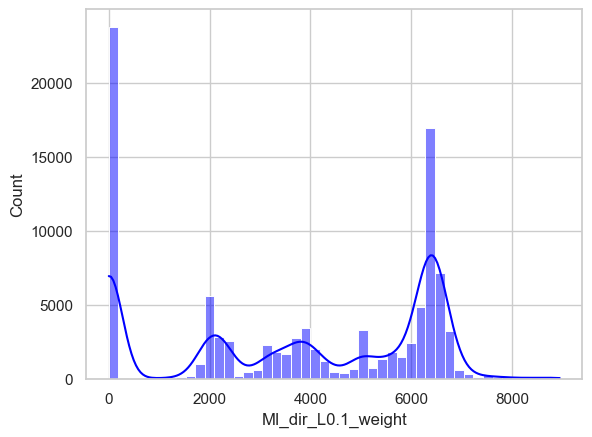

In [ ]:
# EDA
features = df.columns[:5]
sns.histplot(df[features[0]], kde=True, color='blue')
plt.show()

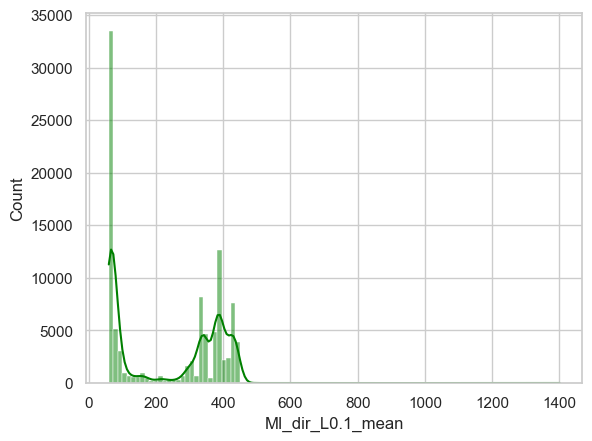

In [ ]:
sns.histplot(df[features[1]], kde=True, color='green')
plt.show()

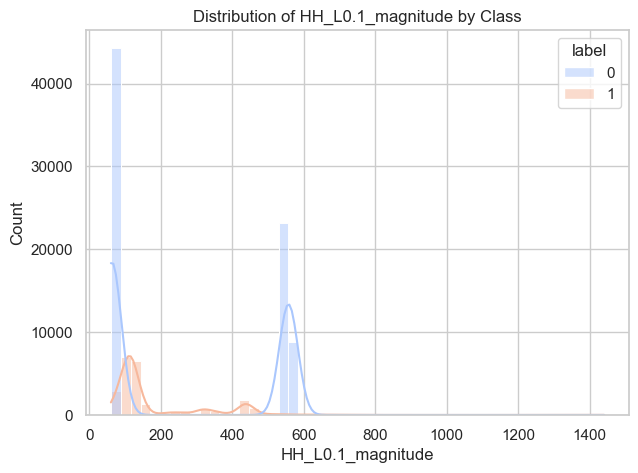

In [ ]:
feature = "HH_L0.1_magnitude"

plt.figure(figsize=(7,5))
sns.histplot(data=df, x=feature, hue="label",
             kde=True, palette="coolwarm", bins=50)
plt.title(f"Distribution of {feature} by Class")
plt.show()

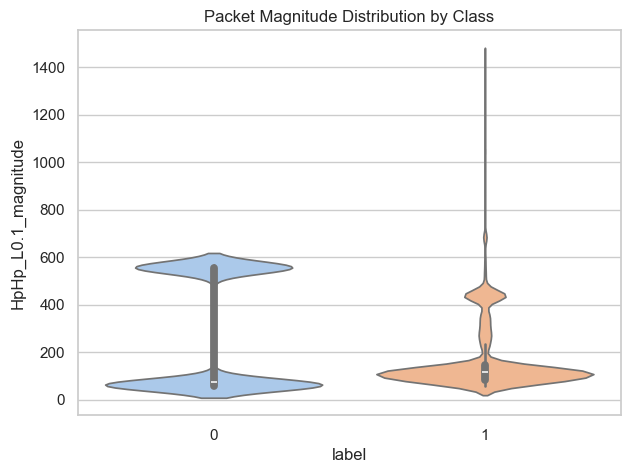

In [ ]:
plt.figure(figsize=(7,5))
sns.violinplot(x="label",
               y="HpHp_L0.1_magnitude",
               data=df,
               palette="pastel")
plt.title("Packet Magnitude Distribution by Class")
plt.show()

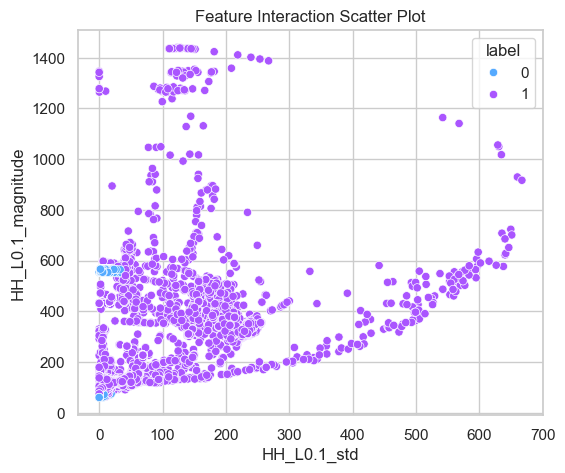

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="HH_L0.1_std",
    y="HH_L0.1_magnitude",
    hue="label",
    data=df,
    palette="cool"
)
plt.title("Feature Interaction Scatter Plot")
plt.show()

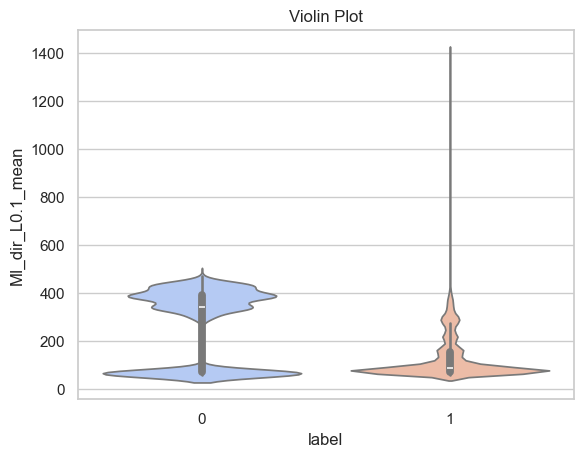

In [ ]:
sns.violinplot(x=df[label_col], y=df[features[1]], palette="coolwarm")
plt.title("Violin Plot")
plt.show()

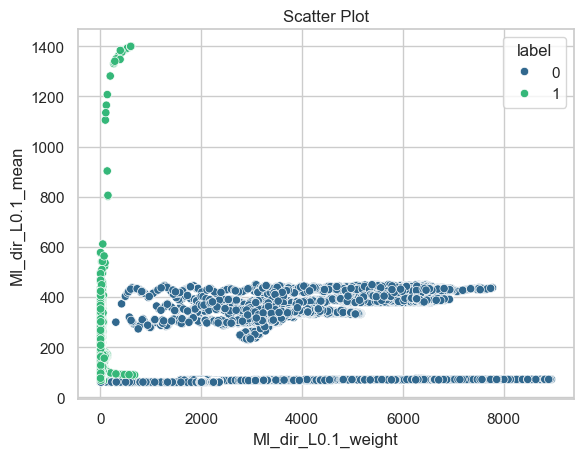

In [ ]:
sns.scatterplot(x=df[features[0]], y=df[features[1]], hue=df[label_col], palette="viridis")
plt.title("Scatter Plot")
plt.show()

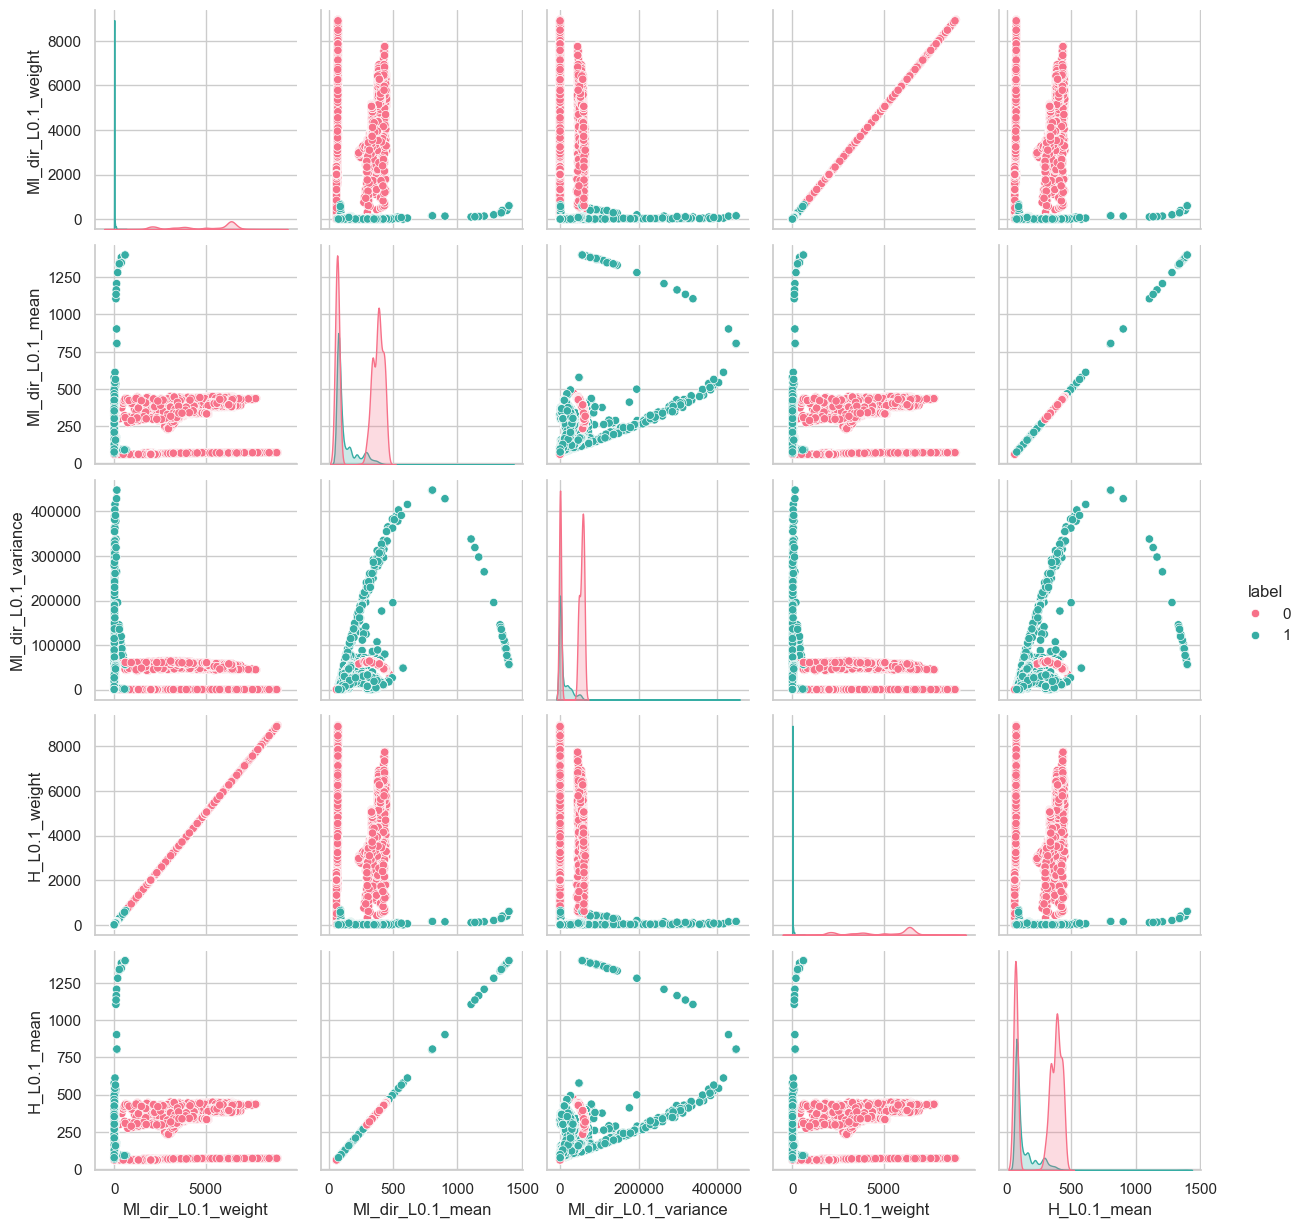

In [ ]:
# Pairplot
sns.pairplot(df[features.tolist() + [label_col]], hue=label_col, palette="husl")
plt.show()

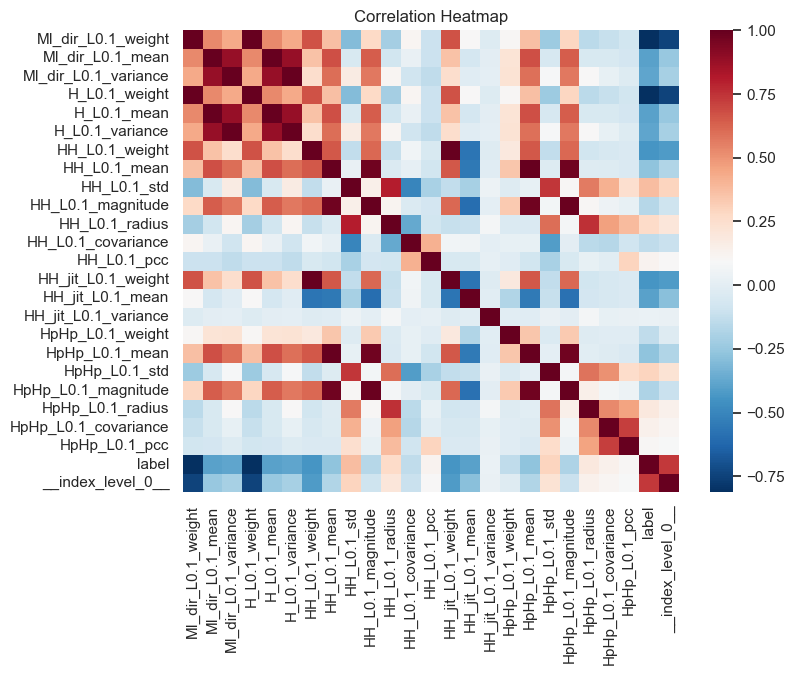

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap="RdBu_r")
plt.title("Correlation Heatmap")
plt.show()

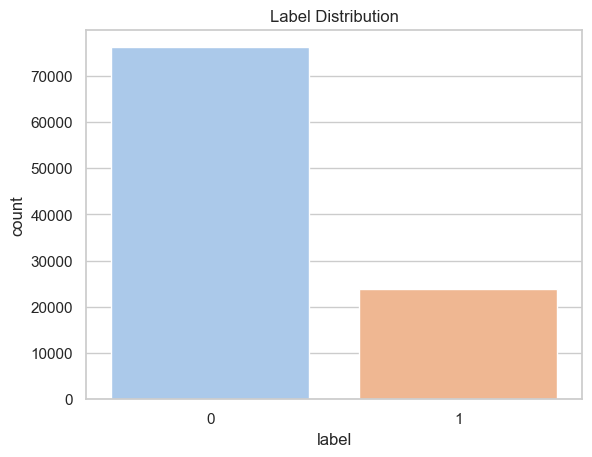

In [ ]:
# Countplot
sns.countplot(x=df[label_col], palette="pastel")
plt.title("Label Distribution")
plt.show()

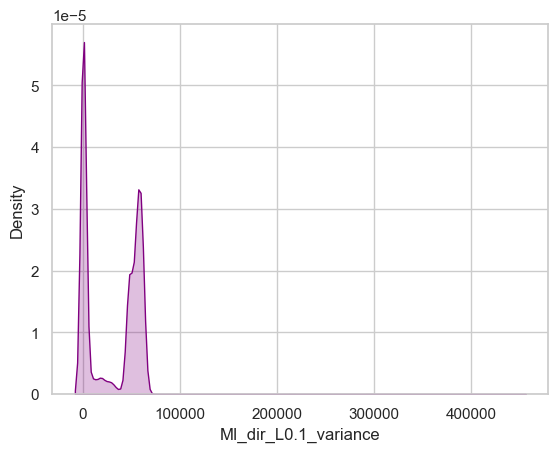

In [ ]:
# KDE Plot
sns.kdeplot(df[features[2]], fill=True, color="purple")
plt.show()

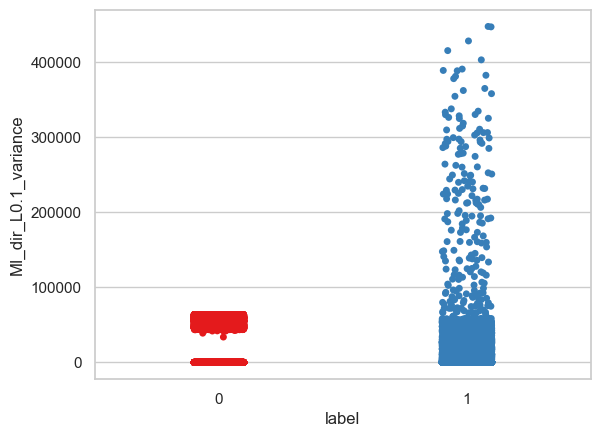

In [ ]:
# Stripplot
sns.stripplot(x=df[label_col], y=df[features[2]], palette="Set1")
plt.show()

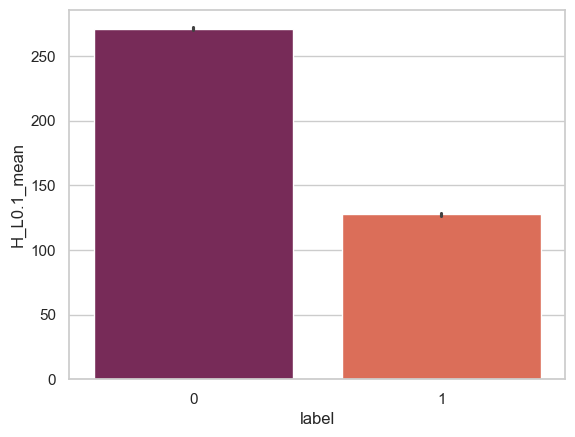

In [ ]:
#Barplot mean
sns.barplot(x=df[label_col], y=df[features[4]], palette="rocket")
plt.show()

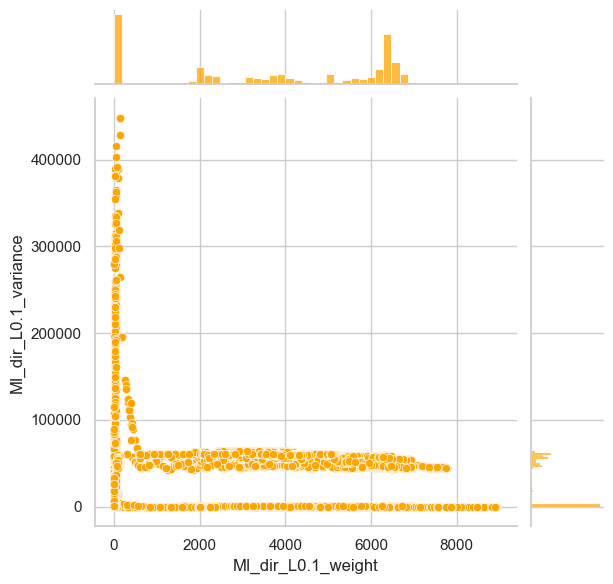

In [ ]:
# Jointplot
sns.jointplot(x=df[features[0]], y=df[features[2]], kind="scatter", color="orange")
plt.show()

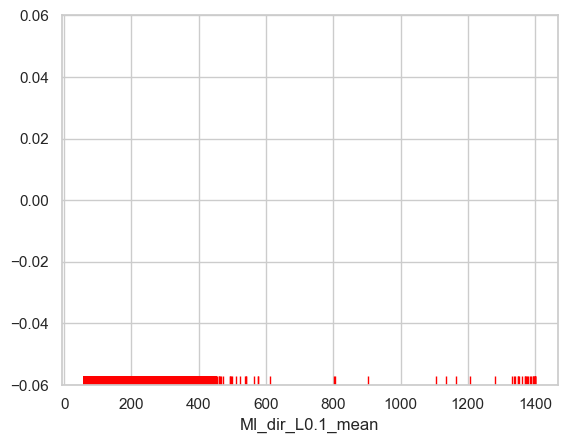

In [ ]:
# Rugplot
sns.rugplot(df[features[1]], color="red")
plt.show()

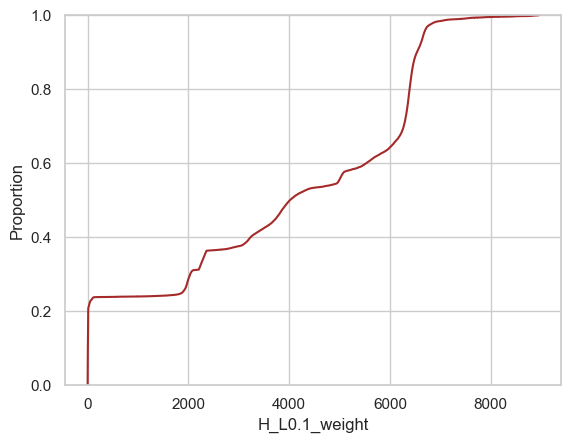

In [ ]:
#ECDF
sns.ecdfplot(df[features[3]], color="brown")
plt.show()

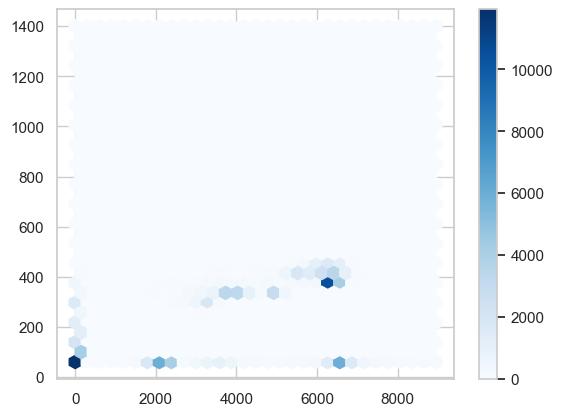

In [ ]:
#Hexbin for MI_dir_L0.1_mean
plt.hexbin(df[features[0]], df[features[1]], gridsize=30, cmap='Blues')
plt.colorbar()
plt.show()

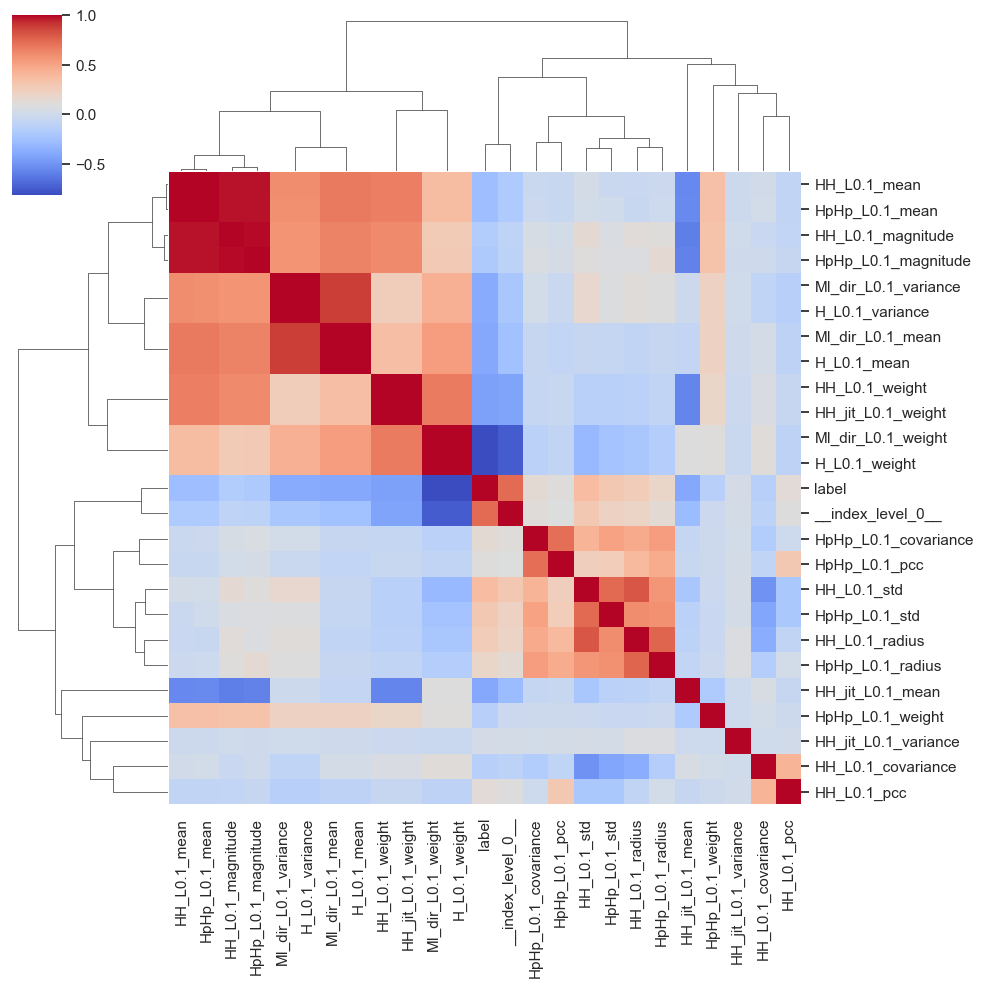

In [ ]:
#Clustermap
sns.clustermap(df.corr(), cmap="coolwarm")
plt.show()

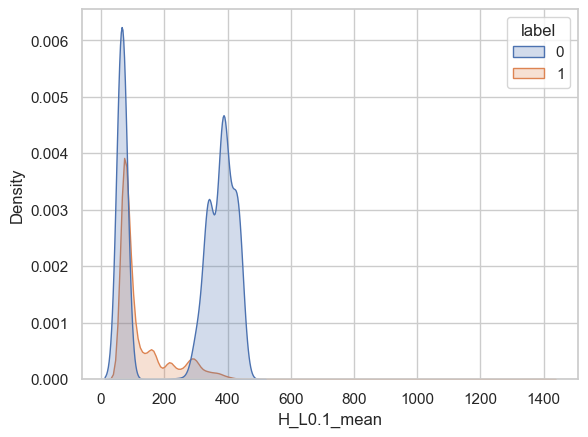

In [ ]:
#Density by class
sns.kdeplot(data=df, x=features[4], hue=label_col, fill=True)
plt.show()

In [ ]:
#Evaluation Function
def evaluate_model(name, y_true, y_pred, y_prob=None, latency=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="binary")
    rec = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")
    if y_prob is not None:
        roc = roc_auc_score(y_true, y_prob)
    else:
        roc = 0.0
    print(f"\n{name} Results")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc, 4))
    # Detection Latency
    if latency is not None:
        print("Detection Latency (sec/sample):", round(latency, 8))

In [ ]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=30, random_state=42)

In [ ]:
start = time.time()
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
end = time.time()
rf_latency = (end - start) / len(X_test)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob, rf_latency)


Random Forest Results
Accuracy : 0.9999
Precision: 0.9999
Recall   : 0.9997
F1 Score : 0.9998
ROC-AUC  : 1.0
Detection Latency (sec/sample): 7.94e-06


In [ ]:
# Isolation Forest
iso = IsolationForest(
    n_estimators=50,
    contamination=0.2,
    random_state=42
)
iso.fit(X_train)

IsolationForest(contamination=0.2, n_estimators=50, random_state=42)

In [ ]:
start = time.time()
iso_pred = iso.predict(X_test)
iso_pred = np.where(iso_pred == -1, 1, 0)
end = time.time()
iso_latency = (end - start) / len(X_test)
evaluate_model("Isolation Forest", y_test, iso_pred, latency=iso_latency)


Isolation Forest Results
Accuracy : 0.7235
Precision: 0.4057
Recall   : 0.342
F1 Score : 0.3711
ROC-AUC  : 0.0
Detection Latency (sec/sample): 1.081e-05


In [ ]:
# One-Class SVM
ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.3
)
ocsvm.fit(X_train)

OneClassSVM(nu=0.3)

In [ ]:
start = time.time()
svm_pred = ocsvm.predict(X_test)
svm_pred = np.where(svm_pred == -1, 1, 0)
end = time.time()
svm_latency = (end - start) / len(X_test)
evaluate_model("One-Class SVM", y_test, svm_pred, latency=svm_latency)


One-Class SVM Results
Accuracy : 0.6825
Precision: 0.3678
Recall   : 0.4605
F1 Score : 0.4089
ROC-AUC  : 0.0
Detection Latency (sec/sample): 0.00856805


In [ ]:
# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)
X_train_t = torch.tensor(
    X_train.reshape(X_train.shape[0], 1, X_train.shape[1]),
    dtype=torch.float32
)
X_test_t = torch.tensor(
    X_test.reshape(X_test.shape[0], 1, X_test.shape[1]),
    dtype=torch.float32
)

In [ ]:
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
model_lstm = LSTMModel(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.01)

In [ ]:
for epoch in range(5):
    optimizer.zero_grad()
    outputs = model_lstm(X_train_t).squeeze()
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
start = time.time()
with torch.no_grad():
    preds = model_lstm(X_test_t).squeeze()
    lstm_binary = (preds > 0.5).int().numpy()
end = time.time()
lstm_latency = (end - start) / len(X_test_t)
evaluate_model("LSTM", y_test, lstm_binary, latency=lstm_latency)


LSTM Results
Accuracy : 0.805
Precision: 1.0
Recall   : 0.1824
F1 Score : 0.3085
ROC-AUC  : 0.0
Detection Latency (sec/sample): 2.44e-06


In [ ]:
# GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_dim):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)
model_gru = GRUModel(X_train.shape[1])
optimizer = optim.Adam(model_gru.parameters(), lr=0.01)

In [ ]:
for epoch in range(5):
    optimizer.zero_grad()
    outputs = model_gru(X_train_t).squeeze()
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
# Measure Detection Latency
start = time.time()
with torch.no_grad():
    preds = model_gru(X_test_t).squeeze()
    gru_binary = (preds > 0.5).int().numpy()
end = time.time()
gru_latency = (end - start) / len(X_test_t)
evaluate_model("GRU", y_test, gru_binary, latency=gru_latency)


GRU Results
Accuracy : 0.9244
Precision: 0.7598
Recall   : 0.9987
F1 Score : 0.863
ROC-AUC  : 0.0
Detection Latency (sec/sample): 1.31e-06


In [ ]:
# 1D CNN Model
class CNN1D(nn.Module):
    def __init__(self, input_dim):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * input_dim, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        return self.sigmoid(x)
X_train_cnn = torch.tensor(
    X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
    dtype=torch.float32
)
X_test_cnn = torch.tensor(
    X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
    dtype=torch.float32
)

In [ ]:
model_cnn = CNN1D(X_train.shape[1])
optimizer = optim.Adam(model_cnn.parameters(), lr=0.01)

In [ ]:
# Training
for epoch in range(5):
    optimizer.zero_grad()
    outputs = model_cnn(X_train_cnn).squeeze()
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

# Measure Detection Latency
start = time.time()
with torch.no_grad():
    preds = model_cnn(X_test_cnn).squeeze()
    cnn_binary = (preds > 0.5).int().numpy()
end = time.time()
cnn_latency = (end - start) / len(X_test_cnn)
evaluate_model("1D CNN", y_test, cnn_binary, latency=cnn_latency)


1D CNN Results
Accuracy : 0.9954
Precision: 0.9955
Recall   : 0.9853
F1 Score : 0.9904
ROC-AUC  : 0.0
Detection Latency (sec/sample): 8e-07


In [ ]:
# COMBINED ROC CURVE
with torch.no_grad():
    lstm_probs = model_lstm(X_test_t).squeeze().numpy()
    gru_probs = model_gru(X_test_t).squeeze().numpy()
    cnn_probs = model_cnn(X_test_cnn).squeeze().numpy()

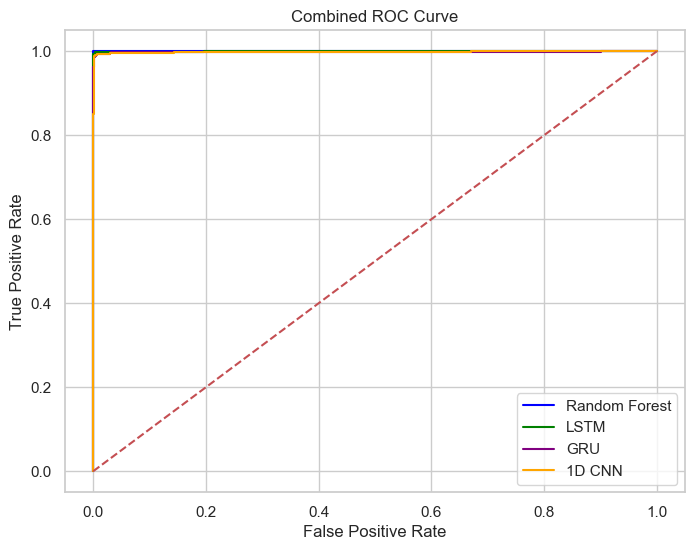

In [ ]:
# RF ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# LSTM ROC
lstm_fpr, lstm_tpr, _ = roc_curve(y_test, lstm_probs)

# GRU ROC
gru_fpr, gru_tpr, _ = roc_curve(y_test, gru_probs)

# CNN ROC
cnn_fpr, cnn_tpr, _ = roc_curve(y_test, cnn_probs)

# Plot Combined ROC
plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label="Random Forest", color="blue")
plt.plot(lstm_fpr, lstm_tpr, label="LSTM", color="green")
plt.plot(gru_fpr, gru_tpr, label="GRU", color="purple")
plt.plot(cnn_fpr, cnn_tpr, label="1D CNN", color="orange")

plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve")
plt.legend()
plt.show()

In [ ]:
#results
results = []

def collect_metrics(name, y_true, y_pred, latency, y_prob=None):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    if y_prob is not None:
        roc = roc_auc_score(y_true, y_prob)
    else:
        roc = 0.0

    results.append([name, acc, prec, rec, f1, roc, latency])

# Collect metrics
collect_metrics("Isolation Forest", y_test, iso_pred, iso_latency)

collect_metrics("One-Class SVM", y_test, svm_pred, svm_latency)

collect_metrics("Random Forest", y_test, rf_pred, rf_latency, rf_prob)

collect_metrics("LSTM", y_test, lstm_binary, lstm_latency)

collect_metrics("GRU", y_test, gru_binary, gru_latency)

collect_metrics("1D CNN", y_test, cnn_binary, cnn_latency)

In [ ]:
# Creating DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Detection Latency"
    ]
)

print(results_df.round(4))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
0  Isolation Forest    0.7235     0.4057  0.3420    0.3711      0.0   
1     One-Class SVM    0.6825     0.3678  0.4605    0.4089      0.0   
2     Random Forest    0.9999     0.9999  0.9997    0.9998      1.0   
3              LSTM    0.8050     1.0000  0.1824    0.3085      0.0   
4               GRU    0.9244     0.7598  0.9987    0.8630      0.0   
5            1D CNN    0.9954     0.9955  0.9853    0.9904      0.0   

   Detection Latency  
0             0.0000  
1             0.0086  
2             0.0000  
3             0.0000  
4             0.0000  
5             0.0000  


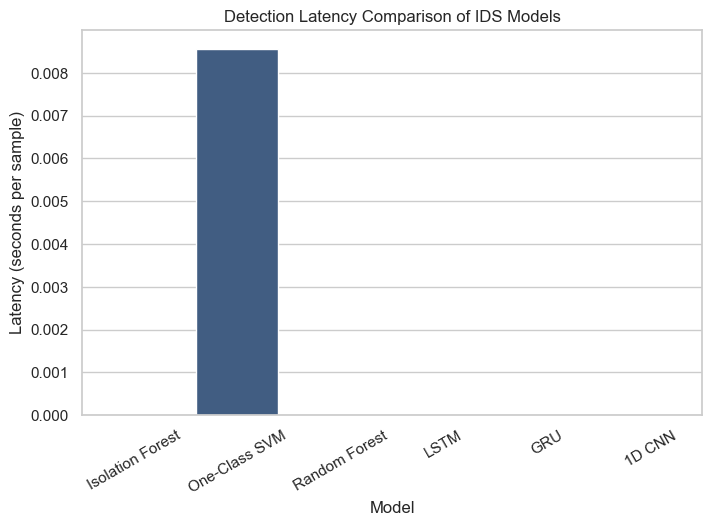

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Detection Latency",
    palette="viridis"
)

plt.title("Detection Latency Comparison of IDS Models")
plt.ylabel("Latency (seconds per sample)")
plt.xlabel("Model")
plt.xticks(rotation=30)

plt.show()

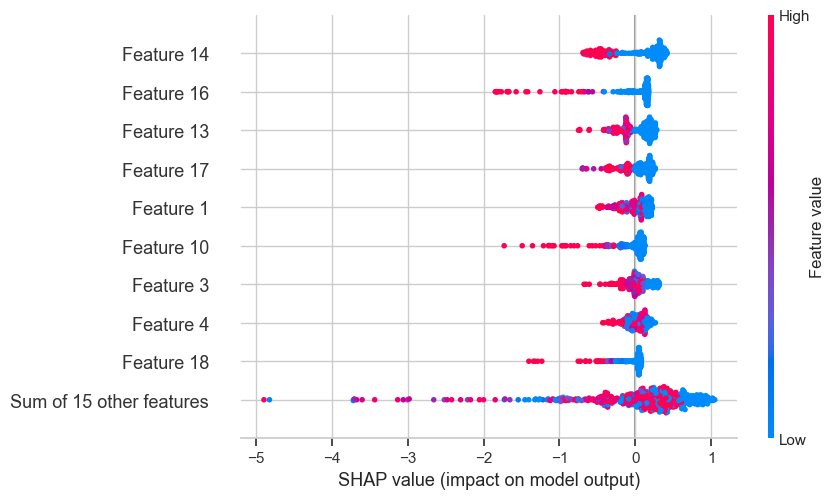

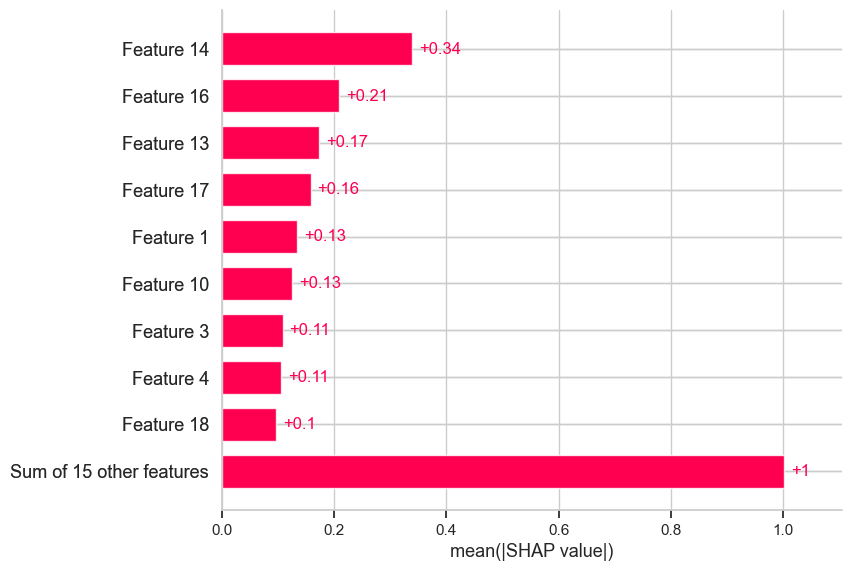

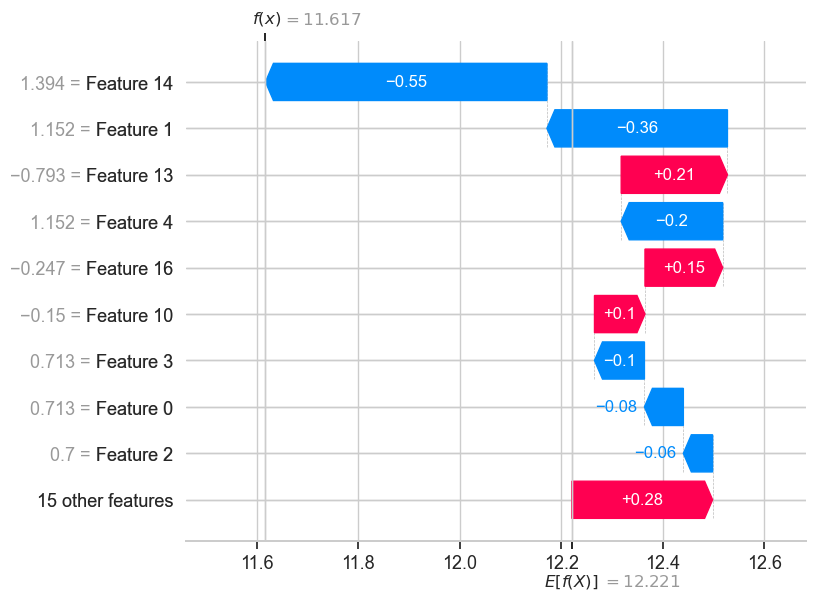

In [ ]:
# Shap for Isolation Forest
explainer_iso = shap.Explainer(iso, X_train[:1000])
shap_values_iso = explainer_iso(X_test[:500])
shap.plots.beeswarm(shap_values_iso)
shap.plots.bar(shap_values_iso)
shap.plots.waterfall(shap_values_iso[0])

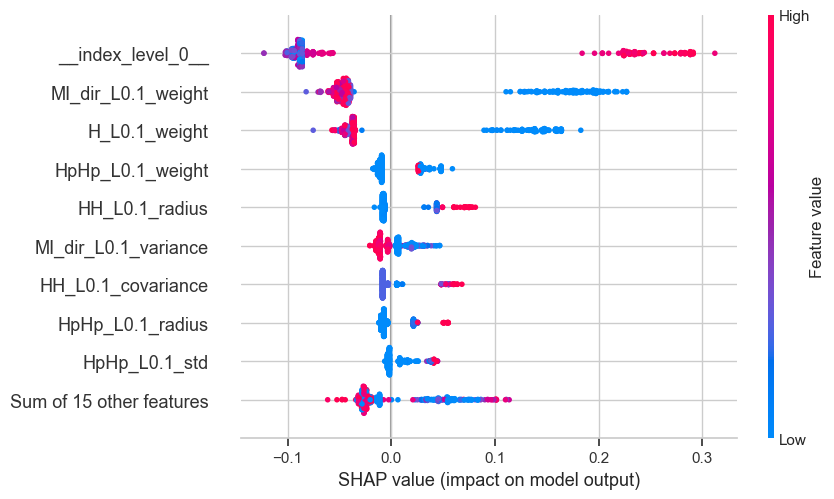

In [ ]:
# Shap for random forest
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf(X_test[:500])
if len(shap_values_rf.values.shape) == 3:
    shap.plots.beeswarm(shap.Explanation(
        values=shap_values_rf.values[:,:,1],
        base_values=shap_values_rf.base_values[:,1],
        data=X_test[:500],
        feature_names=X.columns
    ))
else:
    shap.plots.beeswarm(shap_values_rf)

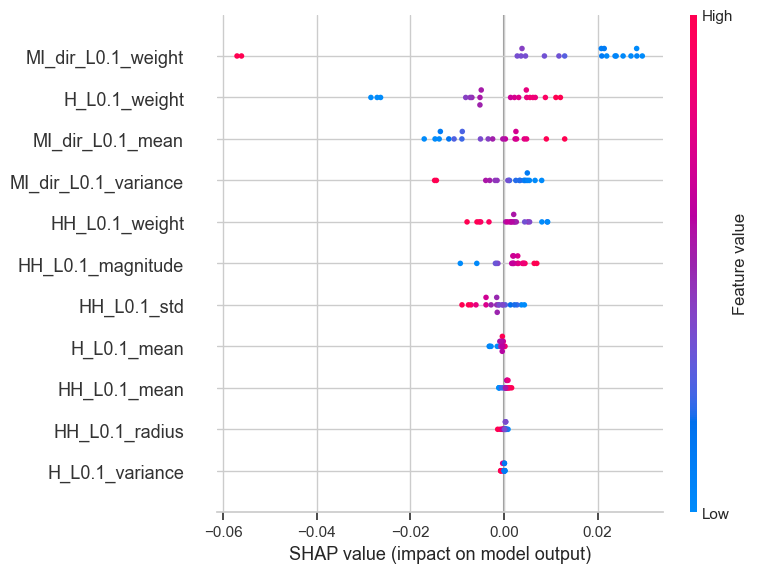

In [ ]:
#LSTM
background = X_train_t[:50]
test_sample = X_test_t[:20]
explainer_lstm = shap.GradientExplainer(model_lstm, background)
shap_values_lstm = explainer_lstm.shap_values(test_sample)
X_shap = test_sample.numpy().reshape(test_sample.shape[0], -1)
shap_vals = np.array(shap_values_lstm).reshape(test_sample.shape[0], -1)
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=X.columns
)

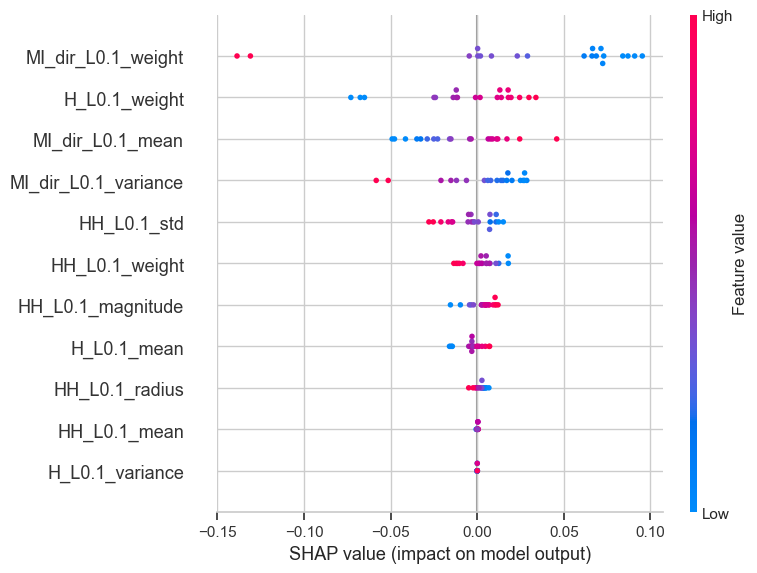

In [ ]:
#GRU
explainer_gru = shap.GradientExplainer(model_gru, background)
shap_values_gru = explainer_gru.shap_values(test_sample)
X_shap = test_sample.numpy().reshape(test_sample.shape[0], -1)
shap_vals = np.array(shap_values_gru).reshape(test_sample.shape[0], -1)
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=X.columns
)

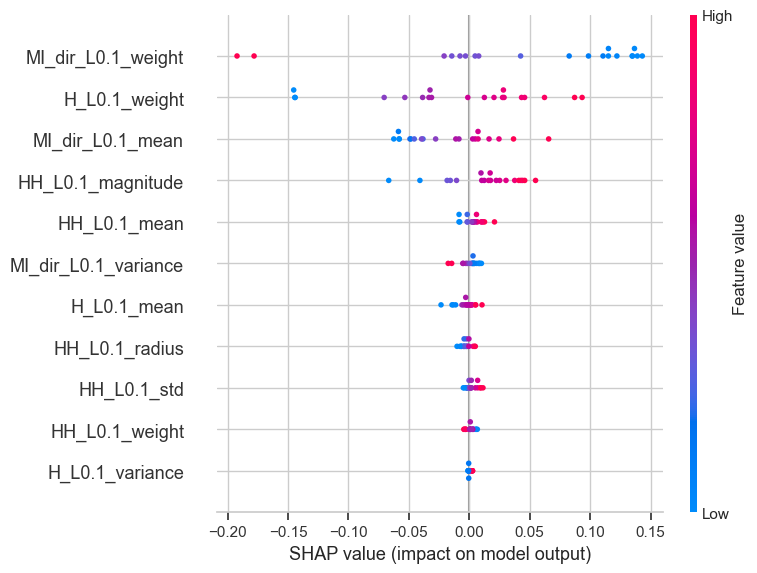

In [ ]:
# CNN
background_cnn = X_train_cnn[:50]
test_sample_cnn = X_test_cnn[:20]
explainer_cnn = shap.GradientExplainer(model_cnn, background_cnn)
shap_values_cnn = explainer_cnn.shap_values(test_sample_cnn)
X_shap = test_sample_cnn.numpy().reshape(test_sample_cnn.shape[0], -1)
shap_vals = np.array(shap_values_cnn).reshape(test_sample_cnn.shape[0], -1)
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=X.columns
)